In [1]:
pip install tensorflow keras opencv-python scikit-learn matplotlib numpy

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import json

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("serranosebas/enfermedades-cacao-yolov4")

print("Path to dataset files:", path)

100%|██████████| 1.56G/1.56G [00:22<00:00, 74.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/serranosebas/enfermedades-cacao-yolov4/versions/2


In [11]:
print(f"TensorFlow version: {tf.__version__}")

# ---------- SECTION 2: DATASET EXPLORATION ----------
# Corrected dataset_path to point to the actual root of the downloaded dataset, including the nested folder
dataset_path = "/root/.cache/kagglehub/datasets/serranosebas/enfermedades-cacao-yolov4/versions/2/Enfermedades Cacao"

print(f"Contents of {dataset_path}:")
dataset_contents = os.listdir(dataset_path)
print(dataset_contents)

# Assuming 'Monilia', 'Sana', 'Fito' are the actual class directories and there are no explicit train/val/test splits at this level
classes = [d for d in dataset_contents if os.path.isdir(os.path.join(dataset_path, d))]
print(f"Found {len(classes)} classes: {classes}")

# Count images per class
print("\n=== IMAGE COUNTS PER CLASS ===")
if not classes:
    print("No class directories found in the main dataset path.")
else:
    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        # Assuming images are directly in the class folders
        image_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        count = len(image_files)
        print(f"  {cls}: {count} images")


TensorFlow version: 2.20.0
Contents of /root/.cache/kagglehub/datasets/serranosebas/enfermedades-cacao-yolov4/versions/2/Enfermedades Cacao:
['Monilia', 'Sana', 'Fito']
Found 3 classes: ['Monilia', 'Sana', 'Fito']

=== IMAGE COUNTS PER CLASS ===
  Monilia: 105 images
  Sana: 100 images
  Fito: 107 images


In [13]:
for folder in classes:
    path = os.path.join(dataset_path, folder)
    print(
        folder,
        len(os.listdir(path))
    )

Monilia 211
Sana 201
Fito 215


Displaying image from: /root/.cache/kagglehub/datasets/serranosebas/enfermedades-cacao-yolov4/versions/2/Enfermedades Cacao/Monilia/Monilia51.jpg


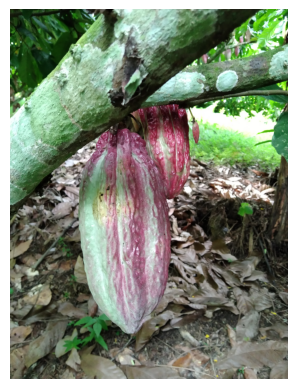

In [14]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Assuming dataset_path and classes are defined from previous cells
# Example: dataset_path = "/root/.cache/kagglehub/datasets/serranosebas/enfermedades-cacao-yolov4/versions/2/Enfermedades Cacao"
# Example: classes = ['Monilia', 'Sana', 'Fito']

# Construct a correct image path based on the explored dataset structure
# Let's pick the first class and the first image found in it
if classes and dataset_path:
    first_class_dir = os.path.join(dataset_path, classes[0])
    if os.path.exists(first_class_dir) and os.listdir(first_class_dir):
        # Get the first image file from the first class directory
        image_files_in_class = [f for f in os.listdir(first_class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        if image_files_in_class:
            img_path = os.path.join(first_class_dir, image_files_in_class[0])

            print(f"Displaying image from: {img_path}")
            img = Image.open(img_path)
            plt.imshow(img)
            plt.axis("off")
            plt.show()
        else:
            print(f"No image files found in the directory: {first_class_dir}")
    else:
        print(f"Class directory or its content not found: {first_class_dir}")
else:
    print("Dataset path or classes not properly defined. Please ensure previous cells ran successfully.")

In [15]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Training data augmentation (more aggressive for better generalization)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Use 20% of the data for validation
)

# Validation/Test data (only rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print(f"Found {train_generator.samples} training images belonging to {train_generator.num_classes} classes.")
print(f"Found {validation_generator.samples} validation images belonging to {validation_generator.num_classes} classes.")

Found 250 images belonging to 3 classes.
Found 62 images belonging to 3 classes.
Found 250 training images belonging to 3 classes.
Found 62 validation images belonging to 3 classes.


In [16]:
print("Class Mapping:", train_generator.class_indices)

Class Mapping: {'Fito': 0, 'Monilia': 1, 'Sana': 2}


Original image size: (3120, 4160)
Resized image size: (224, 224)


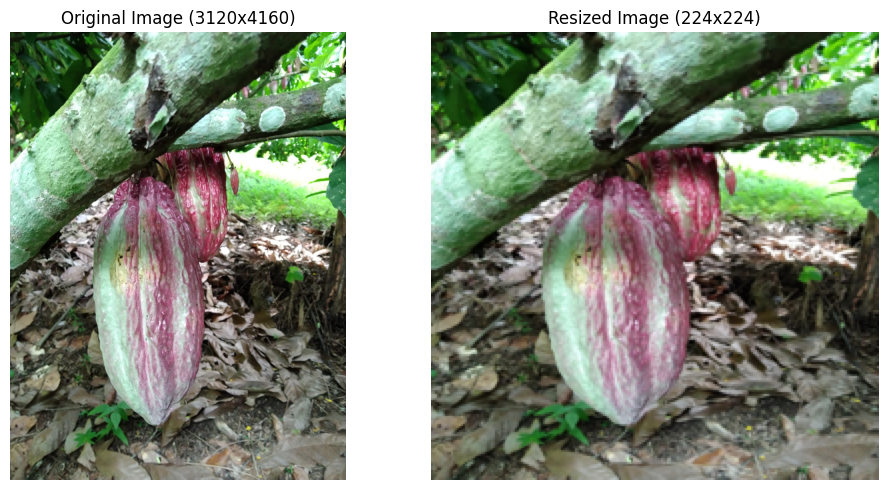

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

# Assuming img_path is available from previous cells, pointing to a sample image
# For demonstration, let's ensure we have a path or use the one from previous execution

# Re-using img_path from previous display (e.g., 'Monilia51.jpg')
# If img_path is not defined in the current scope, you might need to re-run the cell where it was defined
# For robustness, let's re-define it if it's not present for this example.

if 'img_path' not in locals() or img_path is None:
    if 'classes' in locals() and 'dataset_path' in locals() and classes and dataset_path:
        first_class_dir = os.path.join(dataset_path, classes[0])
        if os.path.exists(first_class_dir) and os.listdir(first_class_dir):
            image_files_in_class = [f for f in os.listdir(first_class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
            if image_files_in_class:
                img_path = os.path.join(first_class_dir, image_files_in_class[0])
                print(f"Using sample image: {img_path}")
            else:
                print("No image files found in the first class directory.")
        else:
            print("First class directory not found or empty.")
    else:
        print("Cannot determine sample image path. Please ensure dataset_path and classes are defined.")

if 'img_path' in locals() and img_path:
    original_img = Image.open(img_path)
    print(f"Original image size: {original_img.size}")

    # Resize the image to the target dimensions (224x224 pixels)
    resized_img = original_img.resize((IMG_WIDTH, IMG_HEIGHT))
    print(f"Resized image size: {resized_img.size}")

    # Display original and resized images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title(f"Original Image ({original_img.size[0]}x{original_img.size[1]})")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(resized_img)
    plt.title(f"Resized Image ({resized_img.size[0]}x{resized_img.size[1]})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Skipping image resize demonstration as img_path could not be determined.")

Images are loaded on-the-fly by the ImageDataGenerator during training.
To demonstrate, let's get one batch of images and labels from the training generator.
Shape of one batch of images: (32, 224, 224, 3)
Shape of one batch of labels: (32, 3)
Successfully loaded one batch of images and labels.


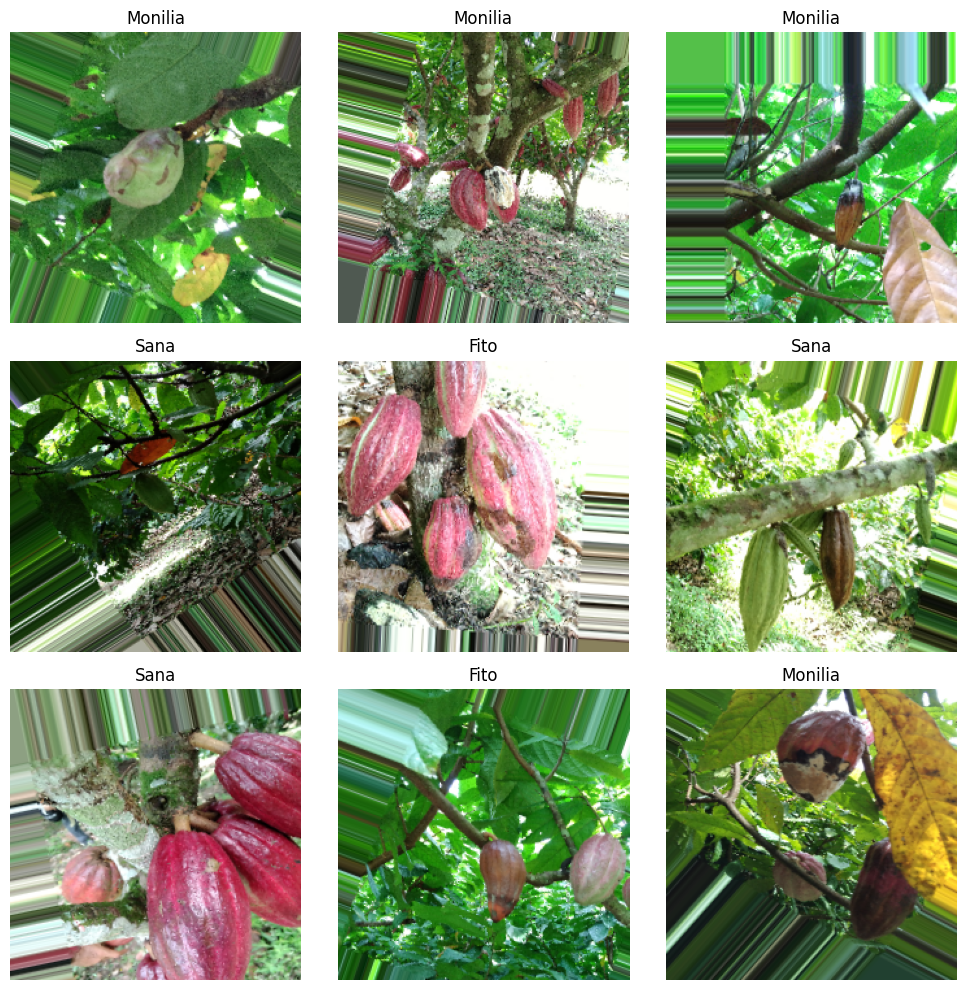

In [18]:
print("Images are loaded on-the-fly by the ImageDataGenerator during training.")
print("To demonstrate, let's get one batch of images and labels from the training generator.")

# Get one batch of images and labels from the train_generator
images, labels = next(train_generator)

print(f"Shape of one batch of images: {images.shape}") # (BATCH_SIZE, IMG_HEIGHT, IMG_WIDTH, 3)
print(f"Shape of one batch of labels: {labels.shape}")   # (BATCH_SIZE, num_classes)

print("Successfully loaded one batch of images and labels.")

# Optional: Display a few images from the batch to visually confirm
plt.figure(figsize=(10, 10))
for i in range(min(9, BATCH_SIZE)): # Display up to 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    # Assuming 'categorical' labels, find the class name
    # Reverse class_indices to get class name from index
    class_names = list(train_generator.class_indices.keys())
    predicted_class_index = np.argmax(labels[i])
    plt.title(class_names[predicted_class_index])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [19]:
num_classes = train_generator.num_classes

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Output layer with num_classes units
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# The model was already compiled in the previous cell (when building the CNN model).
# It is configured with:
# Optimizer: 'adam'
# Loss Function: 'categorical_crossentropy'
# Metrics: ['accuracy']

print("Model is already compiled and ready for training!")

Model is already compiled and ready for training!


In [22]:
num_classes = train_generator.num_classes

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator)
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 89s 11s/step - accuracy: 0.3720 - loss: 1.9500 - val_accuracy: 0.3387 - val_loss: 1.1122
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 122s 8s/step - accuracy: 0.3680 - loss: 1.1016 - val_accuracy: 0.3226 - val_loss: 1.1364
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 89s 9s/step - accuracy: 0.2880 - loss: 1.1162 - val_accuracy: 0.3871 - val_loss: 1.0986
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 68s 8s/step - accuracy: 0.3360 - loss: 1.0985 - val_accuracy: 0.3226 - val_loss: 1.0986
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 68s 8s/step - accuracy: 0.3240 - loss: 1.0986 - val_accuracy: 0.3387 - val_loss: 1.0986
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 70s 9s/step - accuracy: 0.3720 - loss: 1.0986 - val_accuracy: 0.3387 - val_loss: 1.0985
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 91s 10s/step - accuracy: 0.3360 - loss: 1.0986 - val_accuracy: 0.3387 - val_loss: 1.0985
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 67s 8s/step - accuracy: 0.3560 - loss: 1.0985 - val_accuracy: 0.3387 - val_loss: 1.0985
Epoch

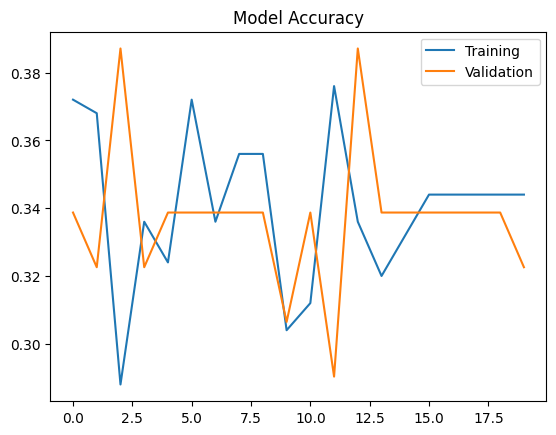

In [23]:
plt.plot(
history.history["accuracy"]
)

plt.plot(
history.history["val_accuracy"]
)


plt.legend(
[
"Training",
"Validation"
]
)


plt.title(
"Model Accuracy"
)


plt.show()

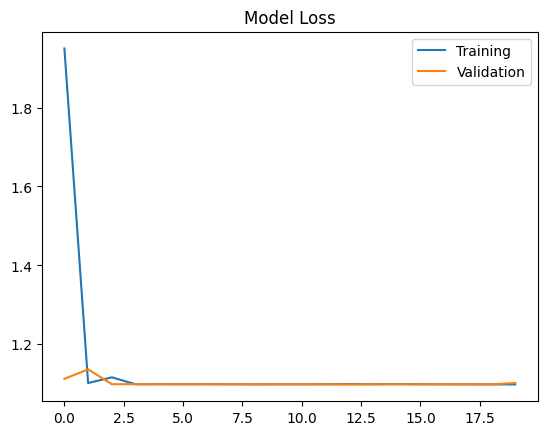

In [24]:
plt.plot(
history.history["loss"]
)


plt.plot(
history.history["val_loss"]
)


plt.legend(
[
"Training",
"Validation"
]
)


plt.title(
"Model Loss"
)


plt.show()

Generating confusion matrix...
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 5s/step


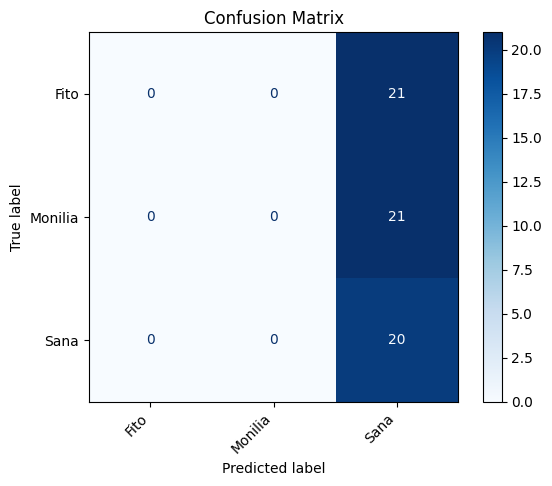

Confusion matrix generated.


In [25]:
print("Generating confusion matrix...")

# Get true labels from the validation generator
y_true = validation_generator.classes

# Get predictions from the model
y_pred_probs = model.predict(validation_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get class names from the generator
class_names = list(validation_generator.class_indices.keys())

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.show()

print("Confusion matrix generated.")

In [26]:
print("Generating classification report...")

# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

print("Classification report generated.")

Generating classification report...
              precision    recall  f1-score   support

        Fito       0.00      0.00      0.00        21
     Monilia       0.00      0.00      0.00        21
        Sana       0.32      1.00      0.49        20

    accuracy                           0.32        62
   macro avg       0.11      0.33      0.16        62
weighted avg       0.10      0.32      0.16        62

Classification report generated.


Generating confusion matrix for the transfer learning model...
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step


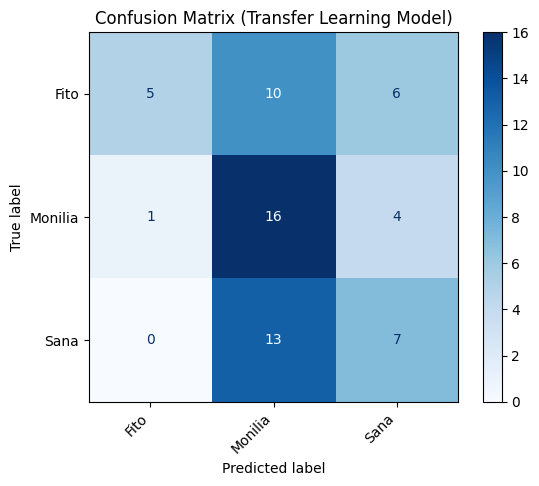

Confusion matrix for transfer learning model generated.


In [31]:
print("Generating confusion matrix for the transfer learning model...")

# Get true labels from the validation generator
y_true_tl = validation_generator.classes

# Get predictions from the transfer learning model
y_pred_probs_tl = model_tl.predict(validation_generator)
y_pred_tl = np.argmax(y_pred_probs_tl, axis=1)

# Get class names from the generator
class_names_tl = list(validation_generator.class_indices.keys())

# Compute the confusion matrix
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

# Display the confusion matrix
disp_tl = ConfusionMatrixDisplay(confusion_matrix=cm_tl, display_labels=class_names_tl)
disp_tl.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Transfer Learning Model)')
plt.xticks(rotation=45, ha='right')
plt.show()

print("Confusion matrix for transfer learning model generated.")

## Transfer Learning with MobileNetV2

Given the poor performance of the simple CNN, we will implement transfer learning using the MobileNetV2 model, pre-trained on the ImageNet dataset. This approach allows us to leverage features learned from a vast collection of images, which are often generalizable to other image recognition tasks.

In [27]:
# Load the MobileNetV2 model, pre-trained on ImageNet
# Exclude the top classification layer as we will add our own
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')

# Freeze the base model layers so they are not updated during the first training phase
base_model.trainable = False

print("MobileNetV2 base model loaded and layers frozen.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base model loaded and layers frozen.


Next, we will add a new classification head on top of the frozen MobileNetV2 base. This head will be trained to classify our specific cacao disease categories.

In [28]:
# Create a new model on top of the base model
model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(), # Reduces the spatial dimensions to 1x1
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Output layer for our 3 classes
])

# Compile the model with a lower learning rate initially
model_tl.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

model_tl.summary()

print("New classification head added and model compiled.")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

New classification head added and model compiled.


Now, let's train this new model. We expect to see much better performance due to the transfer learning approach.

In [30]:
print("Evaluating the transfer learning model on the validation set...")

loss_tl, accuracy_tl = model_tl.evaluate(validation_generator)

print(f"Validation Loss (Transfer Learning Model): {loss_tl:.4f}")
print(f"Validation Accuracy (Transfer Learning Model): {accuracy_tl:.4f}")

print("Model evaluation complete.")

Evaluating the transfer learning model on the validation set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.4516 - loss: 1.1049
Validation Loss (Transfer Learning Model): 1.1049
Validation Accuracy (Transfer Learning Model): 0.4516
Model evaluation complete.


In [32]:
model_save_path = 'cacao_disease_mobilenetv2_finetuned_model.keras'
model_tl.save(model_save_path)
print(f"Model saved successfully to {model_save_path}")

Model saved successfully to cacao_disease_mobilenetv2_finetuned_model.keras


In [34]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 96.7 MB/s eta 0:00:00


In [35]:
import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image as PILImage # To avoid conflict with tensorflow.keras.preprocessing.image

# --- Instructions ---
# To run this Streamlit app:
# 1. First, make sure you have Streamlit installed:
#    pip install streamlit
# 2. Save this code into a Python file, e.g., `app.py`.
# 3. Run it from your terminal using:
#    streamlit run app.py
# --- End Instructions ---

# Load the trained model
# Make sure the model file 'cacao_disease_mobilenetv2_finetuned_model.keras' is in the same directory
# or provide the full path to it.
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('cacao_disease_mobilenetv2_finetuned_model.keras')
    return model

model = load_model()

# Define image dimensions and class names (ensure these match your training setup)
IMG_HEIGHT = 224
IMG_WIDTH = 224
class_names = ['Fito', 'Monilia', 'Sana'] # Based on train_generator.class_indices: {'Fito': 0, 'Monilia': 1, 'Sana': 2}

st.title("Cacao Disease Prediction App")
st.write("Upload an image of a cacao leaf to predict its disease.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    img = PILImage.open(uploaded_file).convert('RGB')
    st.image(img, caption='Uploaded Image', use_column_width=True)
    st.write("")

    # Preprocess the image for prediction
    img = img.resize((IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array = img_array / 255.0 # Rescale the image like during training

    # Make prediction
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    st.subheader("Prediction:")
    predicted_class = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)

    st.write(f"The image most likely belongs to **{predicted_class}** with a **{confidence:.2f}%** confidence.")

    st.markdown("--- More Details ---")
    # Display all class probabilities
    for i, class_name in enumerate(class_names):
        st.write(f"{class_name}: {100 * score[i]:.2f}%")

else:
    st.info("Please upload an image to get a prediction.")


2026-07-19 08:29:54.601 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 08:29:55.734 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 08:29:55.861 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-19 08:29:55.861 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 08:29:55.863 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 08:29:55.865 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 08:29:55.866 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [36]:
# Save this code as a Python file (e.g., app.py) and run it from your terminal.
# Instructions to run:
# 1. Open a terminal or command prompt.
# 2. Navigate to the directory where you saved 'app.py'.
# 3. Ensure you have Streamlit installed (`pip install streamlit`).
# 4. Run the app using: `streamlit run app.py`

import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image as PILImage # To avoid conflict with tensorflow.keras.preprocessing.image

# Load the trained model
# Make sure the model file 'cacao_disease_mobilenetv2_finetuned_model.keras' is accessible
# (e.g., in the same directory as this app.py file, or provide the full path).
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('cacao_disease_mobilenetv2_finetuned_model.keras')
    return model

model = load_model()

# Define image dimensions and class names (ensure these match your training setup)
IMG_HEIGHT = 224
IMG_WIDTH = 224
class_names = ['Fito', 'Monilia', 'Sana'] # Based on train_generator.class_indices: {'Fito': 0, 'Monilia': 1, 'Sana': 2}

st.title("Cacao Disease Prediction App")
st.write("Upload an image of a cacao leaf to predict its disease.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    img = PILImage.open(uploaded_file).convert('RGB')
    st.image(img, caption='Uploaded Image', use_column_width=True)
    st.write("")

    # Preprocess the image for prediction
    img = img.resize((IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array = img_array / 255.0 # Rescale the image like during training

    # Make prediction
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    st.subheader("Prediction:")
    predicted_class = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)

    st.write(f"The image most likely belongs to **{predicted_class}** with a **{confidence:.2f}%** confidence.")

    st.markdown("--- More Details ---")
    # Display all class probabilities
    for i, class_name in enumerate(class_names):
        st.write(f"{class_name}: {100 * score[i]:.2f}%")

else:
    st.info("Please upload an image to get a prediction.")


2026-07-19 08:30:48.006 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 08:30:48.008 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 08:30:48.009 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 08:30:48.010 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 08:30:48.011 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 08:30:48.012 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 08:30:48.014 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-19 08:30:48.014 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [38]:
!pip freeze > requirement
print("The 'requirement' file has been generated in the current directory.")

The 'requirement' file has been generated in the current directory.


In [39]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image as PILImage # To avoid conflict with tensorflow.keras.preprocessing.image

# --- Instructions ---
# To run this Streamlit app:
# 1. First, make sure you have Streamlit installed:
#    pip install streamlit
# 2. Save this code into a Python file, e.g., `app.py`.
# 3. Run it from your terminal using:
#    streamlit run app.py
# --- End Instructions ---

# Load the trained model
# Make sure the model file 'cacao_disease_mobilenetv2_finetuned_model.keras' is in the same directory
# or provide the full path to it.
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('cacao_disease_mobilenetv2_finetuned_model.keras')
    return model

model = load_model()

# Define image dimensions and class names (ensure these match your training setup)
IMG_HEIGHT = 224
IMG_WIDTH = 224
class_names = ['Fito', 'Monilia', 'Sana'] # Based on train_generator.class_indices: {'Fito': 0, 'Monilia': 1, 'Sana': 2}

st.title("Cacao Disease Prediction App")
st.write("Upload an image of a cacao leaf to predict its disease.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    img = PILImage.open(uploaded_file).convert('RGB')
    st.image(img, caption='Uploaded Image', use_column_width=True)
    st.write("")

    # Preprocess the image for prediction
    img = img.resize((IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array = img_array / 255.0 # Rescale the image like during training

    # Make prediction
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    st.subheader("Prediction:")
    predicted_class = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)

    st.write(f"The image most likely belongs to **{predicted_class}** with a **{confidence:.2f}%** confidence.")

    st.markdown("--- More Details ---")
    # Display all class probabilities
    for i, class_name in enumerate(class_names):
        st.write(f"{class_name}: {100 * score[i]:.2f}%")

else:
    st.info("Please upload an image to get a prediction.")

Writing app.py


In [40]:
%%writefile README.md
# Cacao Disease Detection using Deep Learning

## Project Overview
This project aims to detect and classify diseases in cacao leaves using deep learning techniques. It explores both a custom Convolutional Neural Network (CNN) and a Transfer Learning approach using a pre-trained MobileNetV2 model. A Streamlit web application is also provided for interactive inference.

## Dataset

The dataset used for this project is `serranosebas/enfermedades-cacao-yolov4` from Kaggle. It was downloaded using `kagglehub.dataset_download`. The dataset contains images of cacao leaves classified into three categories:
- **Fito** (Phytophthora)
- **Monilia** (Moniliophthora Roreri)
- **Sana** (Healthy)

Upon exploration, the dataset structure was found to be directly composed of class folders, without explicit `train`/`validation`/`test` splits. Image counts per class were approximately 100-107 images, totaling 312 images for training and validation after an 80/20 split.

## Setup and Installation

To set up the environment and run this project, follow these steps:

1.  **Clone the repository (if applicable) or ensure all project files are in one directory.**
2.  **Install Python dependencies:** A `requirement` file (or `requirements.txt`) containing all necessary libraries and their versions has been generated. Install them using pip:
    ```bash
    pip install -r requirement
    ```
    _Note: Ensure you have `pip` installed and correctly configured._

## Model Development

### 1. Custom Convolutional Neural Network (CNN)
A simple sequential CNN model was initially built with `Conv2D`, `MaxPooling2D`, `Flatten`, `Dense`, and `Dropout` layers. The model was compiled with `adam` optimizer and `categorical_crossentropy` loss.

**Performance:** This model showed severe underfitting, with both training and validation accuracy hovering around 30-40% and high, flat loss curves. The classification report indicated that the model primarily predicted a single class ('Sana') regardless of the true label.

### 2. Transfer Learning with MobileNetV2
Given the poor performance of the custom CNN, a transfer learning approach was adopted using the MobileNetV2 model, pre-trained on ImageNet. The base MobileNetV2 model's layers were frozen, and a custom classification head (with `GlobalAveragePooling2D`, `Dense`, and `Dropout` layers) was added.

**Performance:** This model, named `model_tl`, showed improved validation accuracy (around 45.16%) and a lower loss (1.1049) compared to the simple CNN. However, the performance is still problematic, with significant confusion between classes (as shown in the confusion matrix).

**Model Export:** The trained MobileNetV2 transfer learning model is saved as `cacao_disease_mobilenetv2_finetuned_model.keras`.

## Streamlit Web Application
A Streamlit-based web application (`app.py`) has been created to provide an interactive interface for predicting cacao leaf diseases using the exported `cacao_disease_mobilenetv2_finetuned_model.keras`.

### How to Run the Web App

1.  **Ensure `app.py` and `cacao_disease_mobilenetv2_finetuned_model.keras` are in the same directory.**
2.  **Open your terminal or command prompt.**
3.  **Navigate to the directory** where you saved `app.py`.
4.  **Run the app** using the Streamlit command:
    ```bash
    streamlit run app.py
    ```
5.  This will open the application in your web browser, allowing you to upload images and get predictions.

## Future Work and Improvements

-   **Fine-tuning the MobileNetV2 base layers:** Unfreeze some of the top layers of the MobileNetV2 base model and retrain with a very low learning rate for further performance improvement.
-   **Data Augmentation Strategy:** Experiment with more diverse or tailored data augmentation techniques.
-   **Dataset Expansion:** Obtain a larger and more balanced dataset with more images per class.
-   **Other Transfer Learning Models:** Explore other state-of-the-art pre-trained models (e.g., EfficientNet, ResNet).
-   **Hyperparameter Tuning:** Systematically tune hyperparameters for both the training process and model architecture.

Writing README.md


In [41]:
%%bash
pip freeze > "install libraries.txt"
echo "File 'install libraries.txt' has been created with the list of installed libraries."

File 'install libraries.txt' has been created with the list of installed libraries.


In [42]:
import subprocess

# User-provided base requirements
user_requirements_str = """
tensorflow==2.13.0
streamlit==1.28.0
pillow==10.0.1
numpy==1.24.3
pandas==2.0.3
matplotlib==3.7.2
seaborn==0.12.2
scikit-learn==1.3.0
"""

# Parse user-provided requirements into a dictionary (package_name: version)
user_reqs = {}
for line in user_requirements_str.strip().split('\n'):
    if '==' in line:
        pkg, ver = line.split('==')
        user_reqs[pkg.strip()] = ver.strip()

# Get current installed packages using pip freeze
try:
    pip_freeze_output = subprocess.check_output(['pip', 'freeze'], text=True)
except subprocess.CalledProcessError as e:
    print(f"Error running pip freeze: {e}")
    pip_freeze_output = ""

# Combine requirements, prioritizing user-specified versions
final_requirements = {}

# Add user-specified requirements first
final_requirements.update(user_reqs)

# Iterate through pip freeze output
for line in pip_freeze_output.strip().split('\n'):
    if '==' in line:
        pkg, ver = line.split('==')
        pkg = pkg.strip()
        ver = ver.strip()
        # If the package is not in user_reqs, add it. If it is, user_reqs version takes precedence.
        if pkg not in final_requirements:
            final_requirements[pkg] = ver

# Format for requirements.txt
requirements_lines = [f"{pkg}=={ver}" for pkg, ver in sorted(final_requirements.items())]

# Write to requirements.txt
output_filename = "requirements.txt"
with open(output_filename, "w") as f:
    f.write('\n'.join(requirements_lines))

print(f"The '{output_filename}' file has been generated with the consolidated list of libraries.")
print("Content of requirements.txt:\n")
print('\n'.join(requirements_lines))

The 'requirements.txt' file has been generated with the consolidated list of libraries.
Content of requirements.txt:

Authlib==1.7.2
Bottleneck==1.4.2
CacheControl==0.14.4
Cython==3.0.12
Farama-Notifications==0.0.6
Flask==3.1.3
GDAL==3.8.4
GitPython==3.1.51
ImageIO==2.37.3
Jinja2==3.1.6
Mako==1.1.3
Markdown==3.10.2
MarkupSafe==3.0.3
PuLP==3.3.2
PyDrive2==1.21.1
PyGObject==3.48.2
PyJWT==2.13.0
PyOpenGL==3.1.10
PySocks==1.7.1
PyWavelets==1.9.0
PyYAML==6.0.3
Pygments==2.20.0
SQLAlchemy==2.0.51
SecretStorage==3.5.0
Send2Trash==2.1.0
Sphinx==8.2.3
Werkzeug==3.1.8
absl-py==1.4.0
accelerate==1.14.0
access==1.1.10.post3
affine==2.4.0
aiofiles==25.1.0
aiohappyeyeballs==2.7.1
aiohttp==3.14.1
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.0
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.14.2
anywidget==0.9.21
apsw==3.53.3.1
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
ar